In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from sklearn.model_selection import GridSearchCV
from IPython.display import Image, display
from sklearn.metrics import r2_score

# Попробуем предсказать, сколько будет стоит страховка.
# Модель:
Используем линейную регрессию. Так как цель не только научиться предсказывать, но еще и найти зависимости, которые определяют цену страховки (важно для интерпретации работы программы), будем использовать регуляризацию Lasso, потому что она обладает свойством "занулять" некоторые признаки.
# Данные и их предобработка:
Используем датасет insurance. Разделим region с помощью OneHotEncoder, а пол и факт курения с помощью LabelEncoder. Это важно для корректной работы регрессии. Кроме того, данные очень разные, поэтому их мы отнормируем, используя StandardScaler. Кроме того, выборка будет делиться на train и test с помощью train_test_split, это нужно для корректной проверки работы модели.
# Параметры:
Параметры подберем путем перебора и сравнения, используя GridSearchCV.
# Метрики: 
- Коэффициент детерминации R^2. С помощью нее и будем подбирать качество модели и судить о ее качестве. Данная метрика иногда плохо показываем качество модели из-за увелечения числа признаком, но у нас это не так важно, так как признаком мало.
- Кроме того, будем использовать Weighted Absolute Percentage Error (WAPE) - метрика показываем процентое отношение и неплохо интепретируется неспециалистами.

In [155]:
dframe = pd.read_csv("insurance.csv", delimiter=',', index_col=False)
dframe 

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


Так как используем регрессию, 

In [156]:
LE_arr = ['sex', 'smoker']
OHE_arr = ['region']
print("Label Encoder:", LE_arr)
print("One Hot Encoder:", OHE_arr)

Label Encoder: ['sex', 'smoker']
One Hot Encoder: ['region']


In [157]:
dframe2 = dframe.copy()
for obj in LE_arr:
    dframe2[obj] = LabelEncoder().fit_transform(dframe2[obj])
dframe2 = pd.get_dummies(dframe2, columns=OHE_arr, dtype = int)
dframe2

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,0,1,0,0
1334,18,0,31.920,0,0,2205.98080,1,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,0,1


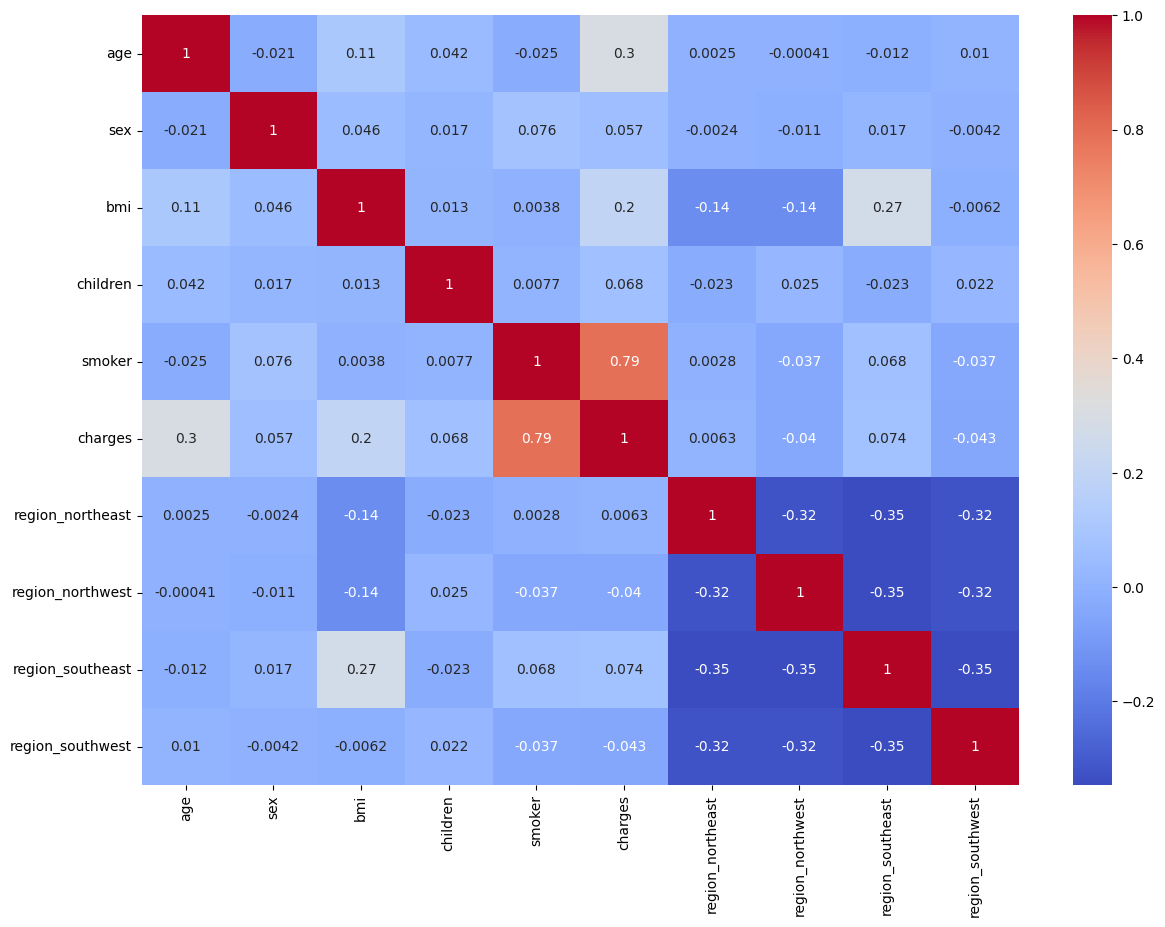

In [158]:
display(Image('Images\Corr.png'))

Видим, что между собой признаки не имеют сильной корреляции между собой - кроме разве что регионов, но это нормально. Значит можно смело пользоваться Lasso.

In [159]:
X_train, X_test, y_train, y_test = train_test_split(dframe2.drop(columns = ['charges']), dframe2['charges'], 
                                                    train_size=0.85,
                                                    random_state = 42)
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
X_train_scaled[0]

array([ 0.90607943,  0.97824881, -0.52118891, -0.90141879,  1.97506002,
       -0.56346881,  1.7662291 , -0.61089148, -0.56888675])

In [160]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [161]:
param_grid = {'alpha': np.logspace(-4, 2, 50), 'max_iter': [i for i in range(1000, 10000 + 1, 1000)], 'tol': [1e-4, 1e-5], 'selection': ['cyclic', 'random']}
model = linear_model.Lasso(alpha = 0.1)
grid_search = GridSearchCV(model, param_grid, cv=10, scoring='r2')
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=10, estimator=Lasso(alpha=0.1),
             param_grid={'alpha': array([1.00000000e-04, 1.32571137e-04, 1.75751062e-04, 2.32995181e-04,
       3.08884360e-04, 4.09491506e-04, 5.42867544e-04, 7.19685673e-04,
       9.54095476e-04, 1.26485522e-03, 1.67683294e-03, 2.22299648e-03,
       2.94705170e-03, 3.90693994e-03, 5.17947468e-03, 6.86648845e-03,
       9.10298178e-03, 1.20679264e-02, 1.59985...
       8.28642773e-01, 1.09854114e+00, 1.45634848e+00, 1.93069773e+00,
       2.55954792e+00, 3.39322177e+00, 4.49843267e+00, 5.96362332e+00,
       7.90604321e+00, 1.04811313e+01, 1.38949549e+01, 1.84206997e+01,
       2.44205309e+01, 3.23745754e+01, 4.29193426e+01, 5.68986603e+01,
       7.54312006e+01, 1.00000000e+02]),
                         'max_iter': [1000, 2000, 3000, 4000, 5000, 6000, 7000,
                                      8000, 9000, 10000],
                         'selection': ['cyclic', 'random'],
                         'tol': [0.0001, 1e-05]},
             scoring='r2')

In [162]:
print("Лучшее R^2:", grid_search.best_score_)
print("Лучшие параметры:", grid_search.best_params_)

Лучшее R^2: 0.7286733498491877
Лучшие параметры: {'alpha': 100.0, 'max_iter': 4000, 'selection': 'random', 'tol': 0.0001}


In [163]:
model = linear_model.Lasso(**grid_search.best_params_) 
model.fit(X_train_scaled, y_train)
for i, col in enumerate(dframe2.drop(columns = ['charges']).columns):
    print(f"Характеристика {col} имеет вес {round(model.coef_[i], 1)}")

Характеристика age имеет вес 3573.6
Характеристика sex имеет вес -0.0
Характеристика bmi имеет вес 1867.9
Характеристика children имеет вес 423.2
Характеристика smoker имеет вес 9471.5
Характеристика region_northeast имеет вес 110.2
Характеристика region_northwest имеет вес 0.0
Характеристика region_southeast имеет вес -0.0
Характеристика region_southwest имеет вес -7.5


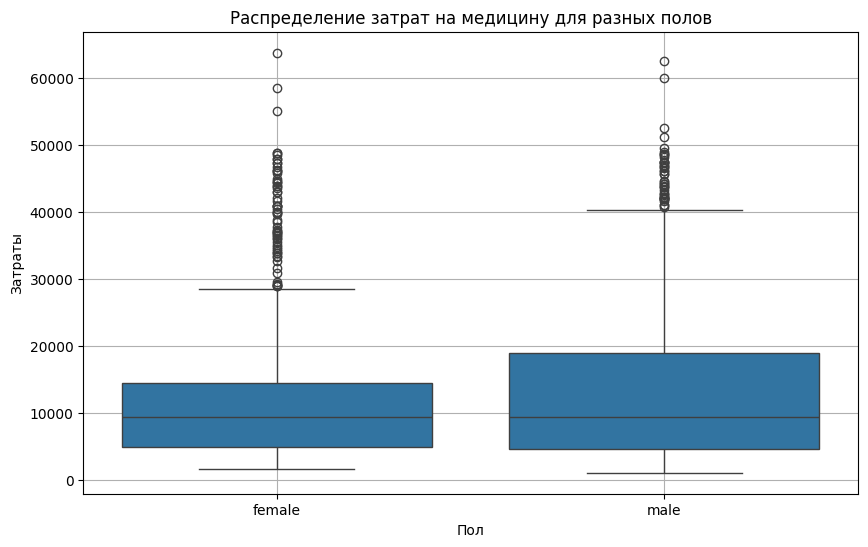

In [164]:
display(Image('Images\Boxplot_sex.png'))

Видим, что веса регрессии подтверждают матрицу корреляции. В Graphics.ipynb выяснили, что больше всего на цену страховки влияют именно:
- Курение
- Возраст
- Индекс Массы Тела\
Именно у этих характеристик веса больше тысячи. Причем чем выше корреляция, тем больше вес признака. Стоит отметить, что на 4 месте идет количество детей, но оно уступает тому же ИМТ в несколько раз. Возможно, стоило применть OHE для данного признака. Видим, что регион не влияет, разве что незначительно. Это может быть просто случайный шум.
Важно отметить, что вес признака пол вообще обнулился. Это говорит о том, что пол не влияет на цену страховки как и регион. Если вспомнить boxplot, то можно заметить, что медианы и правда одинаковы, но разброс у мужчин в затратах все-таки больше. 

Посмотрим на тестовый выборке на качество работы модели.

In [165]:
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

In [166]:
y_pred = model.predict(X_test_scaled)

r2_m = r2_score(y_test, y_pred)
WAPE_m = wape(y_test, y_pred)

print(f"Коэффициент детерминации на тестовой выборке: {round(r2_m, 2)}")
print(f"Средняя абсолютная процентная ошибка на тестовой выборке: {round(WAPE_m, 1)}%")

Коэффициент детерминации на тестовой выборке: 0.79
Средняя абсолютная процентная ошибка на тестовой выборке: 30.5%


В итоге получаем модель которая работает лучше среднего, но которая еще не очень хороша. Средняя ошибка при этом достигает 30 процентов, что не мало. Если человеку нужно всего лишь "прикинуть" цену, то этого будет достаточно. R^2 тем временем близок к 80 процентам, но не достигает их. 
С помощью данной модели можно примерно найти цену страховки, однако для бОльшей точности требуется либо больше признаков, либо модель получше.